# 03 · EDA: análisis multivariado, hipótesis y hallazgos

**Evento evaluativo 2 – Análisis de Datos (ITM, 2026-2)**
**Fase 2 del proyecto (segunda parte).** Responsable del módulo: David.

En el notebook 02 miramos cada variable por separado. Aquí las cruzamos para responder la pregunta del proyecto: **¿qué características de una reserva se asocian con que termine cancelada?**

1. Cancelación frente a variables categóricas
2. Cancelación frente a variables numéricas
3. Correlaciones: Pearson frente a Spearman
4. Tablas cruzadas: cuando dos variables actúan juntas
5. Comportamiento en el tiempo
6. Hipótesis y pruebas estadísticas
7. Hallazgos principales, problemas de calidad y líneas futuras

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
AZUL, NARANJA, GRIS = "#0072B2", "#D55E00", "#6E6E6E"
COLOR_HOTEL = {"City Hotel": "#0072B2", "Resort Hotel": "#E69F00"}

URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"

def limpiar(datos):
    """Decisiones de calidad justificadas en el notebook 02."""
    d = datos.copy()
    d["children"] = d["children"].fillna(0).astype(int)
    d["country"] = d["country"].fillna("Desconocido")
    d["tiene_agente"] = d["agent"].notna().astype(int)
    d["tiene_empresa"] = d["company"].notna().astype(int)
    d["agent"] = d["agent"].fillna(0).astype(int).astype(str)
    d = d.drop(columns="company")
    d["meal"] = d["meal"].replace("Undefined", "SC")
    d["huespedes"] = d["adults"] + d["children"] + d["babies"]
    d["noches"] = d["stays_in_weekend_nights"] + d["stays_in_week_nights"]
    d = d[(d["huespedes"] > 0) & (d["adr"] >= 0) & (d["adr"] < 1000)]
    return d.reset_index(drop=True)


df = limpiar(pd.read_csv(URL))
TASA_BASE = df["is_canceled"].mean() * 100
print(f"Reservas: {len(df):,} | Tasa de cancelación global: {TASA_BASE:.1f} %")

Reservas: 119,208 | Tasa de cancelación global: 37.1 %


## 1. Cancelación frente a variables categóricas

Para cada categoría calculamos el porcentaje de reservas canceladas y lo comparamos con la tasa global (línea punteada). Una barra muy por encima o muy por debajo de la línea indica que esa categoría se comporta distinto al promedio.

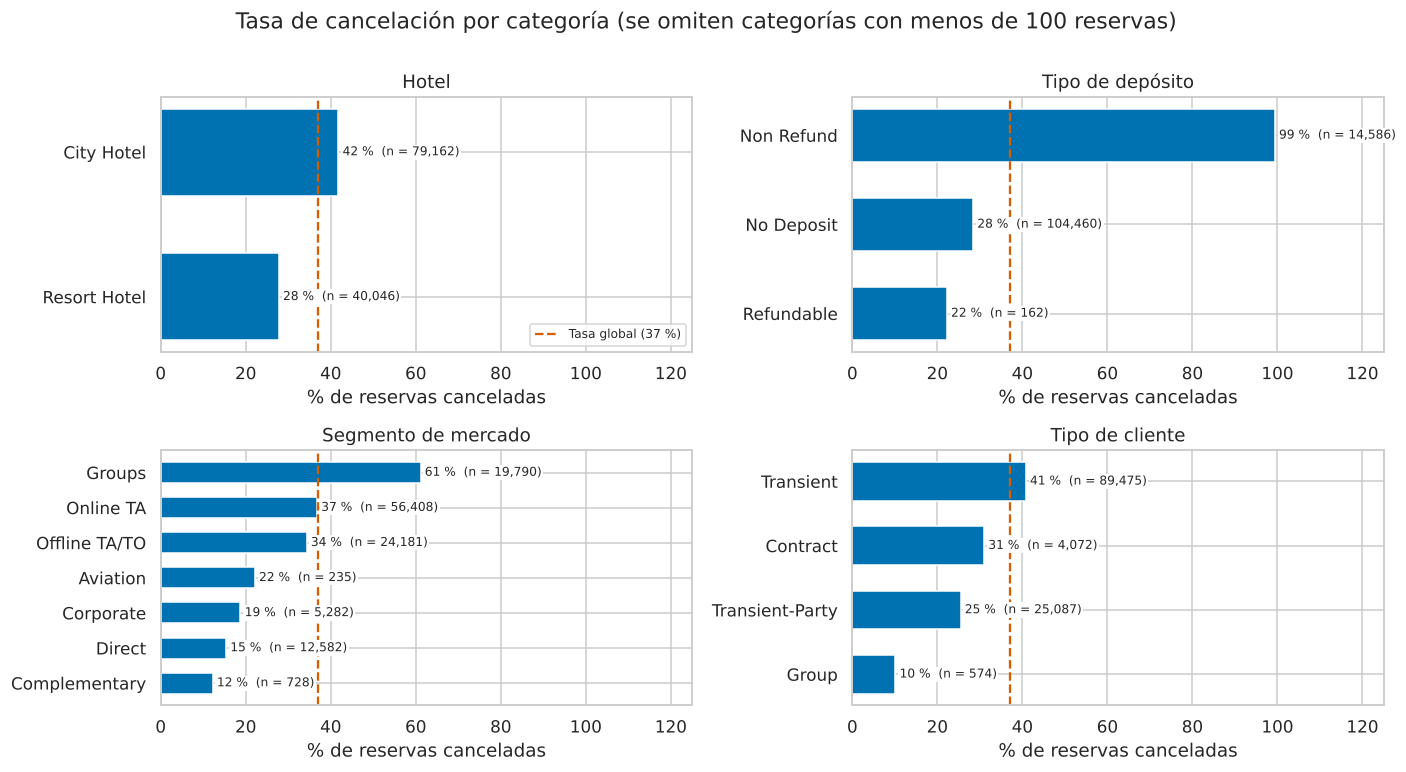

In [2]:
def tasa_por(col, datos=df):
    """Tasa de cancelación (%) y número de reservas por categoría."""
    t = datos.groupby(col)["is_canceled"].agg(tasa="mean", reservas="size")
    t["tasa"] = t["tasa"] * 100
    return t.sort_values("tasa")


cat_cols = ["hotel", "deposit_type", "market_segment", "customer_type"]
titulos = ["Hotel", "Tipo de depósito", "Segmento de mercado", "Tipo de cliente"]

fig, ax = plt.subplots(2, 2, figsize=(13, 7))
for eje, col, titulo in zip(ax.ravel(), cat_cols, titulos):
    t = tasa_por(col)
    t = t[t["reservas"] >= 100]                       # categorías con muy pocas reservas dan tasas inestables
    barras = eje.barh(t.index, t["tasa"], color=AZUL, height=0.6)
    for b, n in zip(barras, t["reservas"]):
        eje.text(b.get_width() + 1, b.get_y() + b.get_height() / 2, f"{b.get_width():.0f} %  (n = {n:,})", va="center", fontsize=8,
                 bbox={"facecolor": "white", "edgecolor": "none", "pad": 1}, zorder=4)
    eje.axvline(TASA_BASE, color=NARANJA, linestyle="--", linewidth=1.5, zorder=1, label=f"Tasa global ({TASA_BASE:.0f} %)")
    eje.set(title=titulo, xlabel="% de reservas canceladas", xlim=(0, 125))
ax[0, 0].legend(loc="lower right", fontsize=8)
fig.suptitle("Tasa de cancelación por categoría (se omiten categorías con menos de 100 reservas)", y=1.0)
plt.tight_layout()
plt.show()

**Interpretación.**

- El hotel de ciudad cancela más (42 %) que el resort (28 %).
- Lo más raro está en el depósito: las reservas *Non Refund* (no reembolsables) se cancelan el **99 %** de las veces. Esperábamos lo contrario, porque si no devuelven la plata uno pensaría que la gente no cancela. Lo revisamos más a fondo en la sección 4.
- Por segmento, los grupos cancelan 61 % y las reservas directas solo 15 %.
- Por tipo de cliente, *Transient* (cliente ocasional) cancela 41 % y *Group* 10 %.

## 2. Cancelación frente a variables numéricas

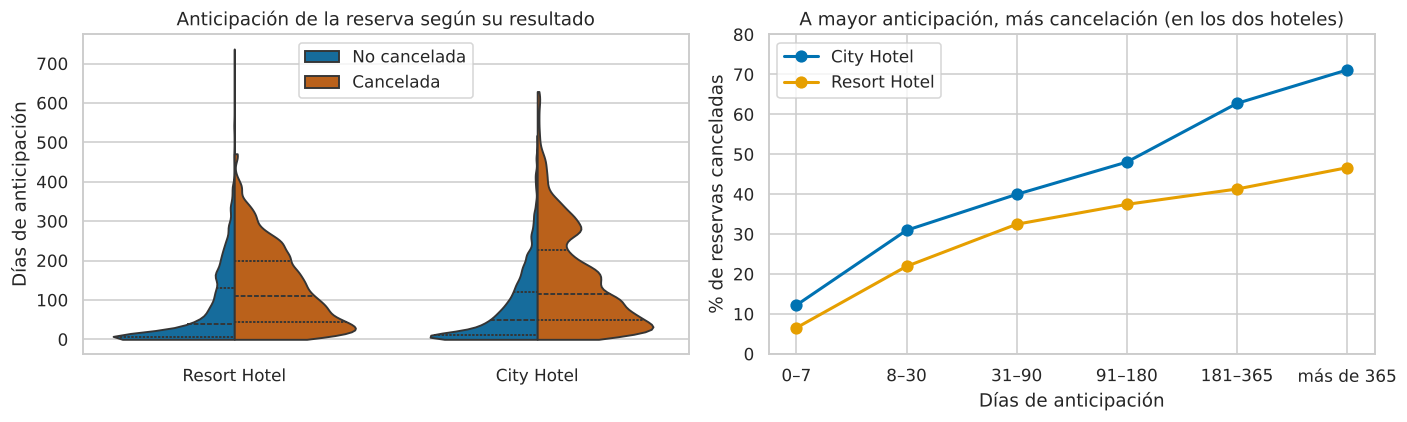

hotel       City Hotel  Resort Hotel
tramo                               
0–7               12.2           6.5
8–30              30.9          21.9
31–90             39.9          32.5
91–180            48.0          37.4
181–365           62.7          41.3
más de 365        71.1          46.6


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Violín: distribución completa de la anticipación según el resultado de la reserva
aux = df.assign(resultado=df["is_canceled"].map({0: "No cancelada", 1: "Cancelada"}))
sns.violinplot(data=aux, x="hotel", y="lead_time", hue="resultado", split=True, inner="quart", cut=0,
               palette={"No cancelada": AZUL, "Cancelada": NARANJA}, ax=ax[0])
ax[0].set(title="Anticipación de la reserva según su resultado", xlabel="", ylabel="Días de anticipación")
ax[0].legend(title="")

# Tasa de cancelación por tramos de anticipación
tramos = [-1, 7, 30, 90, 180, 365, 800]
etiquetas = ["0–7", "8–30", "31–90", "91–180", "181–365", "más de 365"]
aux["tramo"] = pd.cut(aux["lead_time"], bins=tramos, labels=etiquetas)
tasa_tramo = aux.groupby(["tramo", "hotel"], observed=True)["is_canceled"].mean().mul(100).unstack()
for h in tasa_tramo.columns:
    ax[1].plot(tasa_tramo.index.astype(str), tasa_tramo[h], marker="o", linewidth=2, markersize=7, color=COLOR_HOTEL[h], label=h)
ax[1].set(title="A mayor anticipación, más cancelación (en los dos hoteles)", xlabel="Días de anticipación",
          ylabel="% de reservas canceladas", ylim=(0, 80))
ax[1].legend(title="")
plt.tight_layout()
plt.show()

print(tasa_tramo.round(1).to_string())

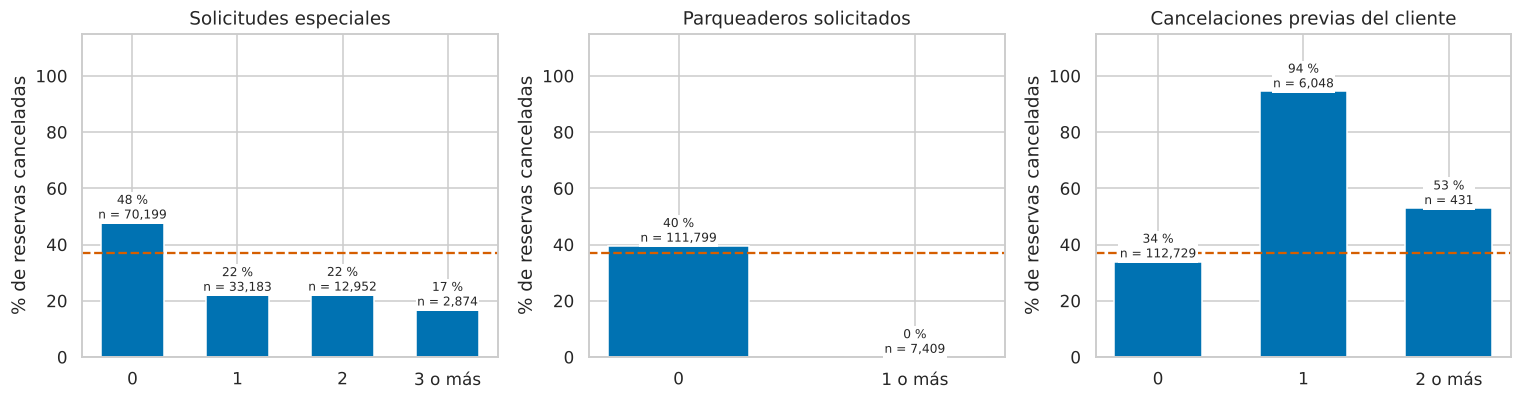

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for eje, col, titulo, tope in zip(ax, ["total_of_special_requests", "required_car_parking_spaces", "previous_cancellations"],
                                  ["Solicitudes especiales", "Parqueaderos solicitados", "Cancelaciones previas del cliente"], [3, 1, 2]):
    grupo = df[col].clip(upper=tope)
    t = df.groupby(grupo)["is_canceled"].agg(tasa="mean", n="size")
    nombres = [f"{int(v)}" if v < tope else f"{int(v)} o más" for v in t.index]
    barras = eje.bar(nombres, t["tasa"] * 100, color=AZUL, width=0.6)
    for b, n in zip(barras, t["n"]):
        eje.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.5, f"{b.get_height():.0f} %\nn = {n:,}", ha="center", fontsize=8,
                 bbox={"facecolor": "white", "edgecolor": "none", "pad": 1}, zorder=4)
    eje.axhline(TASA_BASE, color=NARANJA, linestyle="--", linewidth=1.5, zorder=1)
    eje.set(title=titulo, ylabel="% de reservas canceladas", ylim=(0, 115))
plt.tight_layout()
plt.show()

**Interpretación.**

- La anticipación es la variable numérica que más se relaciona con la cancelación. En el hotel de ciudad la tasa sube de 12 % (reservas de la misma semana) a 71 % (más de un año). En el resort pasa lo mismo, de 6,5 % a 47 %, así que no es algo de un solo hotel.
- Quien hace al menos una solicitud especial cancela cerca de 22 %, frente a 48 % de quien no pide nada.
- Con parqueadero la cancelación es 0 %: de 7.400 reservas, ninguna se canceló. Nos pareció demasiado perfecto. Creemos que el parqueadero se registra cuando el huésped llega al hotel y no cuando reserva; si es así, esa variable no serviría para predecir, porque solo existe cuando ya se sabe que no canceló. La dejamos marcada como sospechosa.
- En cancelaciones previas pasa algo raro: con exactamente una la tasa es 94 %, y con dos o más baja a 53 %. Al revisar vimos que más de la mitad de esas reservas son no reembolsables y tres de cada cuatro son filas repetidas, que es lo mismo que explicamos en la sección 4.

## 3. Correlaciones: Pearson frente a Spearman

Pearson mide relación **lineal** y es sensible a valores extremos. Spearman trabaja con rangos: mide relación **monótona** y resiste mejor los extremos. En el notebook 02 vimos que casi todas las variables son muy asimétricas, así que comparamos los dos.

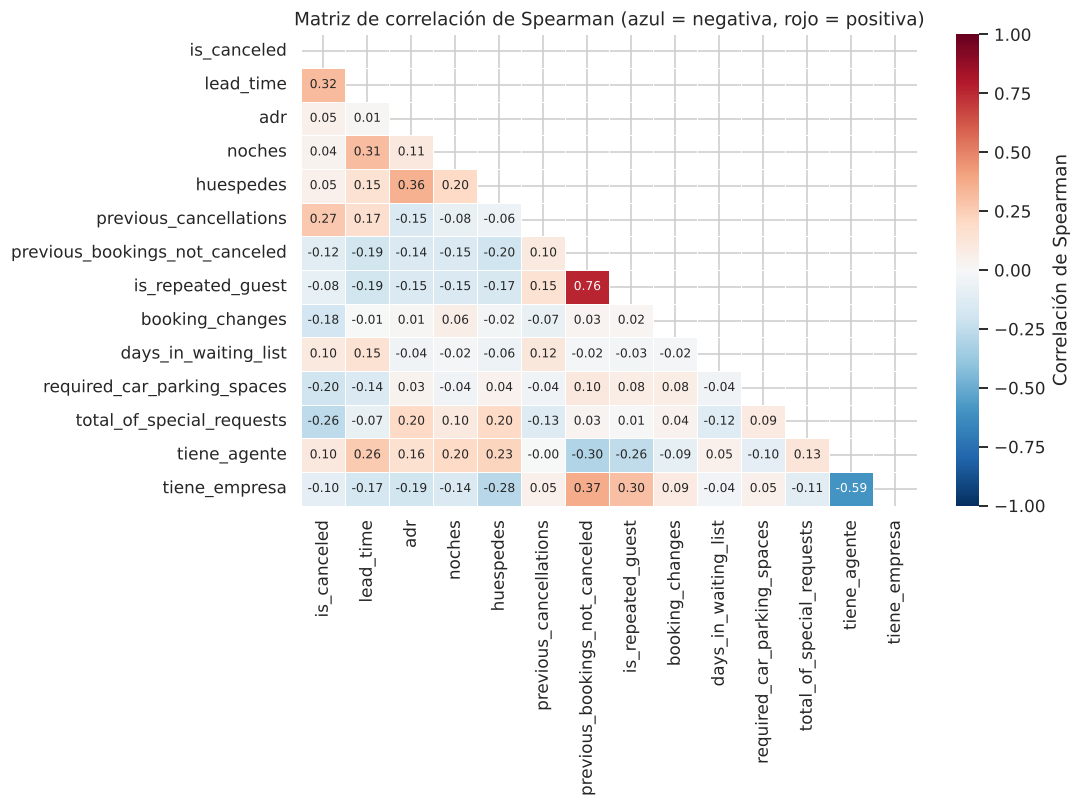

In [5]:
num_cols = ["is_canceled", "lead_time", "adr", "noches", "huespedes", "previous_cancellations",
            "previous_bookings_not_canceled", "is_repeated_guest", "booking_changes", "days_in_waiting_list",
            "required_car_parking_spaces", "total_of_special_requests", "tiene_agente", "tiene_empresa"]

pearson = df[num_cols].corr(method="pearson")
spearman = df[num_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 7.5))
mascara = np.triu(np.ones_like(spearman, dtype=bool))
sns.heatmap(spearman, mask=mascara, cmap="RdBu_r", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8}, linewidths=0.5, cbar_kws={"label": "Correlación de Spearman"}, ax=ax)
ax.set_title("Matriz de correlación de Spearman (azul = negativa, rojo = positiva)")
plt.tight_layout()
plt.show()

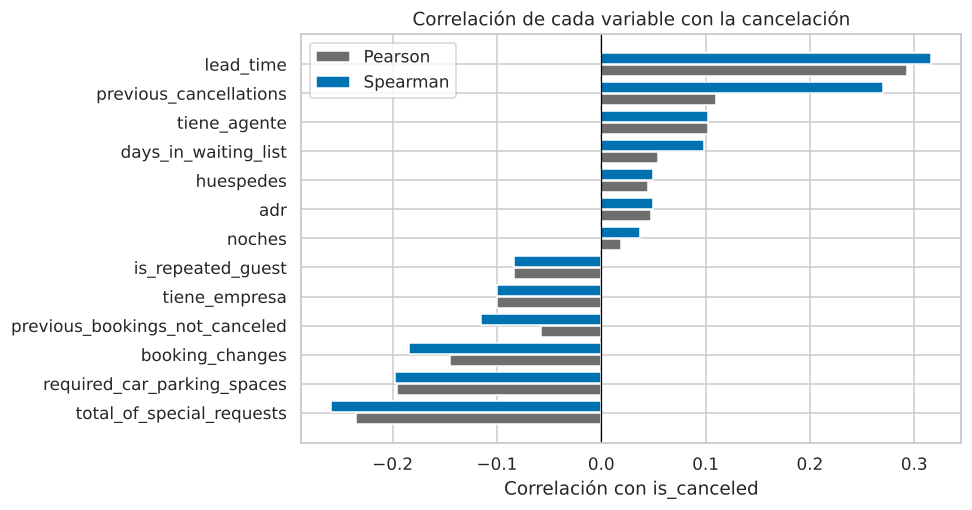

,Pearson,Spearman,diferencia
total_of_special_requests,-0.235,-0.259,0.024
required_car_parking_spaces,-0.196,-0.198,0.002
booking_changes,-0.145,-0.184,0.039
previous_bookings_not_canceled,-0.057,-0.115,0.058
tiene_empresa,-0.100,-0.100,-0.000
is_repeated_guest,-0.084,-0.084,0.000
noches,0.019,0.037,0.018
adr,0.048,0.050,0.002
huespedes,0.045,0.050,0.005
days_in_waiting_list,0.054,0.098,0.044


In [6]:
comparacion = pd.DataFrame({"Pearson": pearson["is_canceled"], "Spearman": spearman["is_canceled"]}).drop("is_canceled")
comparacion["diferencia"] = comparacion["Spearman"].abs() - comparacion["Pearson"].abs()
comparacion = comparacion.sort_values("Spearman")

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(comparacion))
ax.barh(y - 0.2, comparacion["Pearson"], height=0.38, color=GRIS, label="Pearson")
ax.barh(y + 0.2, comparacion["Spearman"], height=0.38, color=AZUL, label="Spearman")
ax.set_yticks(y)
ax.set_yticklabels(comparacion.index)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(xlabel="Correlación con is_canceled", title="Correlación de cada variable con la cancelación")
ax.legend()
plt.tight_layout()
plt.show()

comparacion.round(3)

**Interpretación.**

- Ninguna correlación con la cancelación pasa de 0,32. La más alta es la de `lead_time`. O sea que no hay una sola variable numérica que explique la cancelación.
- Pearson y Spearman no dan lo mismo. En `previous_cancellations` Pearson da 0,11 y Spearman 0,27. Esa variable vale cero en el 95 % de los casos y tiene valores extremos de hasta 26, y Pearson es sensible a eso. Como casi todas las variables de esta base son sesgadas, nos parece más adecuado usar Spearman.
- Entre las variables explicativas, la relación más fuerte es entre `is_repeated_guest` y `previous_bookings_not_canceled` (0,76). Tiene sentido porque solo un huésped repetido puede tener reservas anteriores. Son variables que dicen casi lo mismo.
- `adr` casi no se correlaciona con cancelar (0,05). Pensábamos que el precio iba a ser importante y no lo es, al menos por sí solo. Lo probamos en las hipótesis.
- Hay que recordar que correlación no es causalidad: reservar con anticipación no causa la cancelación; puede ser simplemente que hay más tiempo para que cambien los planes.

## 4. Tablas cruzadas: cuando dos variables actúan juntas

Volvemos al resultado extraño de la sección 1: ¿por qué se cancela el 99 % de las reservas no reembolsables? Cruzamos el tipo de depósito con el segmento de mercado.

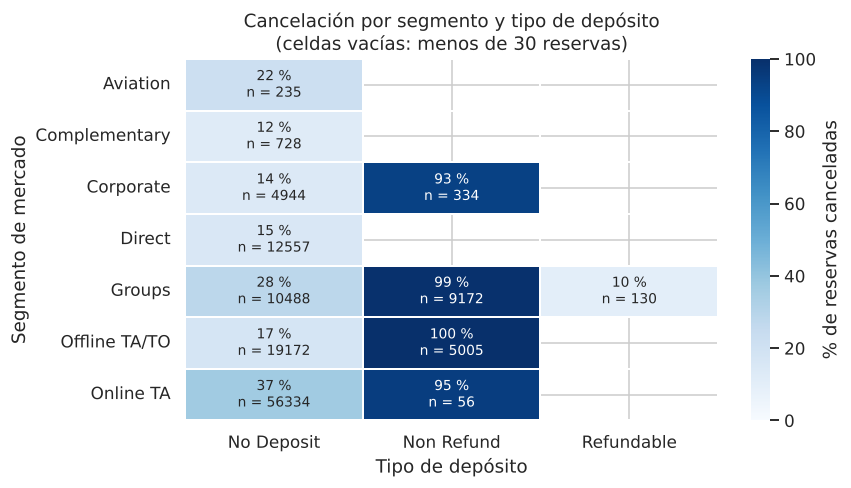

In [7]:
tasa = df.pivot_table(index="market_segment", columns="deposit_type", values="is_canceled", aggfunc="mean") * 100
n = df.pivot_table(index="market_segment", columns="deposit_type", values="is_canceled", aggfunc="size").fillna(0)

tasa = tasa.drop(index="Undefined").where(n >= 30)       # se ocultan celdas con menos de 30 reservas
n = n.loc[tasa.index]
texto = tasa.round(0).astype("Int64").astype(str) + " %\nn = " + n.astype(int).astype(str)
texto = texto.where(tasa.notna(), "")

fig, ax = plt.subplots(figsize=(8, 4.6))
sns.heatmap(tasa, annot=texto, fmt="", cmap="Blues", vmin=0, vmax=100, linewidths=1,
            cbar_kws={"label": "% de reservas canceladas"}, annot_kws={"size": 9}, ax=ax)
ax.set(title="Cancelación por segmento y tipo de depósito\n(celdas vacías: menos de 30 reservas)", xlabel="Tipo de depósito", ylabel="Segmento de mercado")
plt.tight_layout()
plt.show()

In [8]:
# ¿Quiénes son las reservas 'Non Refund'? Las comparamos con el resto.
nr = df["deposit_type"] == "Non Refund"

perfil = pd.DataFrame({
    "Non Refund": [nr.sum(),
                   (df.loc[nr, "country"] == "PRT").mean() * 100,
                   df.loc[nr, "market_segment"].isin(["Groups", "Offline TA/TO"]).mean() * 100,
                   (df.loc[nr, "hotel"] == "City Hotel").mean() * 100,
                   (df.loc[nr, "total_of_special_requests"] > 0).mean() * 100,
                   df.loc[nr, "lead_time"].median(),
                   df[nr].duplicated().mean() * 100],
    "Resto": [(~nr).sum(),
              (df.loc[~nr, "country"] == "PRT").mean() * 100,
              df.loc[~nr, "market_segment"].isin(["Groups", "Offline TA/TO"]).mean() * 100,
              (df.loc[~nr, "hotel"] == "City Hotel").mean() * 100,
              (df.loc[~nr, "total_of_special_requests"] > 0).mean() * 100,
              df.loc[~nr, "lead_time"].median(),
              df[~nr].duplicated().mean() * 100],
}, index=["Reservas", "% desde Portugal", "% por grupos o agencia tradicional", "% en el hotel de ciudad",
          "% con alguna solicitud especial", "Mediana de anticipación (días)", "% de filas repetidas"]).round(1)
perfil

,Non Refund,Resto
Reservas,14586.0,104622.0
% desde Portugal,97.2,32.8
% por grupos o agencia tradicional,97.2,28.5
% en el hotel de ciudad,88.2,63.4
% con alguna solicitud especial,0.2,46.8
Mediana de anticipación (días),183.0,57.0
% de filas repetidas,92.9,17.6


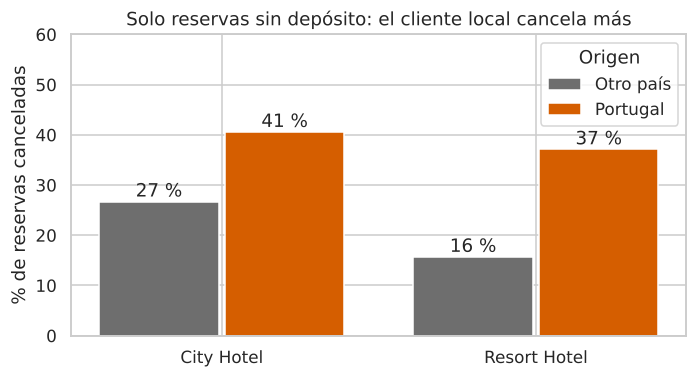

In [9]:
# Portugal frente al resto del mundo, controlando por hotel y por depósito
aux = df.assign(origen=np.where(df["country"] == "PRT", "Portugal", "Otro país"))
cruce = aux[aux["deposit_type"] == "No Deposit"].groupby(["hotel", "origen"])["is_canceled"].mean().mul(100).unstack()

fig, ax = plt.subplots(figsize=(6.5, 3.6))
x = np.arange(len(cruce))
ax.bar(x - 0.2, cruce["Otro país"], width=0.38, color=GRIS, label="Otro país")
ax.bar(x + 0.2, cruce["Portugal"], width=0.38, color=NARANJA, label="Portugal")
for i, (a, b) in enumerate(zip(cruce["Otro país"], cruce["Portugal"])):
    ax.text(i - 0.2, a + 1, f"{a:.0f} %", ha="center")
    ax.text(i + 0.2, b + 1, f"{b:.0f} %", ha="center")
ax.set_xticks(x)
ax.set_xticklabels(cruce.index)
ax.set(ylabel="% de reservas canceladas", ylim=(0, 60), title="Solo reservas sin depósito: el cliente local cancela más")
ax.legend(title="Origen")
plt.tight_layout()
plt.show()

**Interpretación.**

- Al revisar quiénes son las reservas *Non Refund* vimos que son un grupo muy particular: el 97 % viene de Portugal, el 97 % entra por grupos o agencias tradicionales, casi ninguna tiene solicitudes especiales, se hacen con una mediana de 183 días de anticipación y el **93 % son filas repetidas**.
- Por eso creemos que son reservas en bloque de agencias u operadores turísticos, que apartan muchas habitaciones con anticipación y después las cancelan. Esto es una hipótesis nuestra: con los datos no podemos confirmarlo.
- Entonces no es que el depósito cause la cancelación, sino que ese tipo de depósito lo usa casi solo un tipo de cliente que cancela mucho. Sería una variable de confusión.
- Esto importa porque un modelo aprendería la regla "Non Refund = cancela", que no aplicaría para un cliente individual.
- El efecto del país se mantiene aunque dejemos solo las reservas sin depósito y separemos por hotel: el cliente de Portugal cancela más que el extranjero. Puede ser porque el turista internacional ya compró tiquetes y al local le queda más fácil cambiar de plan.

## 5. Comportamiento en el tiempo

La base cubre llegadas entre julio de 2015 y agosto de 2017. Miramos la tarifa y la cancelación mes a mes.

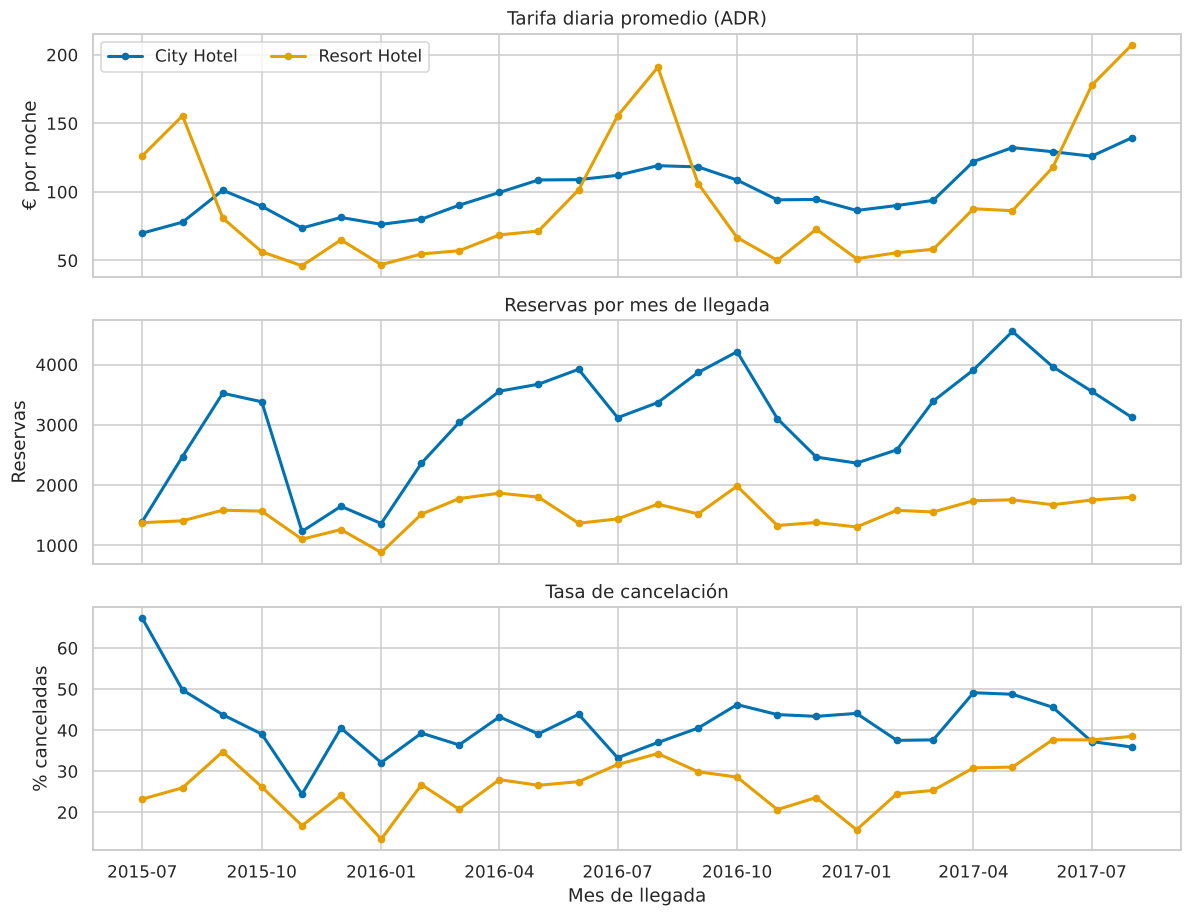

In [10]:
MESES = {m: i for i, m in enumerate(["January", "February", "March", "April", "May", "June", "July", "August",
                                     "September", "October", "November", "December"], start=1)}
fecha = pd.to_datetime(dict(year=df["arrival_date_year"], month=df["arrival_date_month"].map(MESES), day=1))
mensual = df.assign(fecha=fecha).groupby(["fecha", "hotel"]).agg(
    reservas=("is_canceled", "size"), cancelacion=("is_canceled", "mean"), adr=("adr", "mean")).reset_index()
mensual["cancelacion"] *= 100

fig, ax = plt.subplots(3, 1, figsize=(11, 8.5), sharex=True)
for eje, col, titulo, ylab in zip(ax, ["adr", "reservas", "cancelacion"],
                                  ["Tarifa diaria promedio (ADR)", "Reservas por mes de llegada", "Tasa de cancelación"],
                                  ["€ por noche", "Reservas", "% canceladas"]):
    for h, g in mensual.groupby("hotel"):
        eje.plot(g["fecha"], g[col], marker="o", markersize=4, linewidth=2, color=COLOR_HOTEL[h], label=h)
    eje.set(title=titulo, ylabel=ylab)
ax[0].legend(title="", ncol=2, loc="upper left")
ax[2].set_xlabel("Mes de llegada")
plt.tight_layout()
plt.show()

**Interpretación.**

- El resort tiene una estacionalidad muy marcada y el hotel de ciudad no. La tarifa del resort pasa de unos 50 € en invierno a más de 200 € en agosto de 2017, y baja mucho en septiembre. La del hotel de ciudad sube poco a poco.
- En los dos hoteles cada verano es más caro que el anterior.
- La cancelación no se mueve igual que el precio. En el resort la tarifa se multiplica por cuatro entre invierno y agosto y la cancelación sube unos 15 puntos. En el hotel de ciudad, el mes con más cancelación (julio de 2015, 67 %) fue el más barato. Esto coincide con la correlación baja entre `adr` y `is_canceled`.
- Usamos tres gráficas con el mismo eje de tiempo en lugar de una sola con dos ejes verticales, porque con dos escalas distintas es fácil que la gráfica sugiera una relación que no existe.
- Solo hay 26 meses de datos, o sea dos veranos completos y parte de otro. Sirve para describir la estacionalidad, pero no alcanza para modelarla.

### Vista conjunta (pairplot)

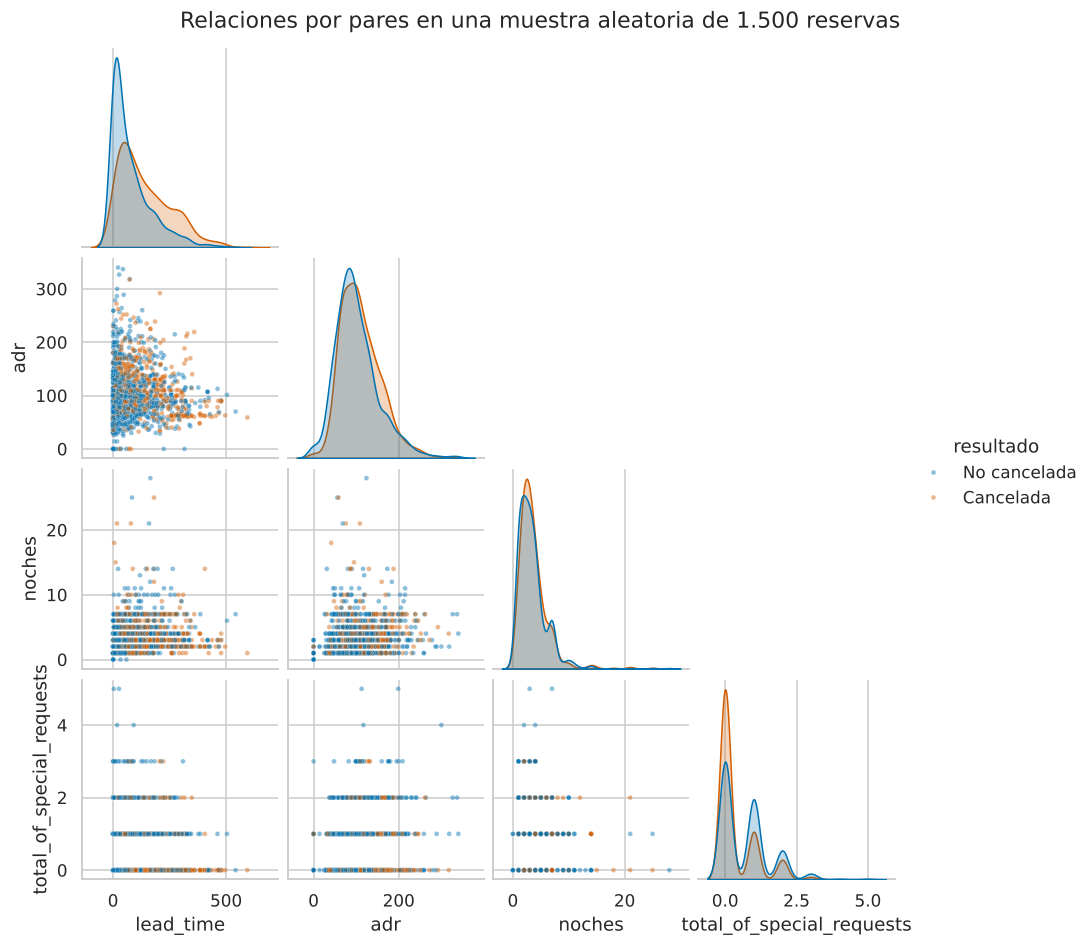

In [11]:
muestra = df.sample(1500, random_state=42).assign(
    resultado=lambda d: d["is_canceled"].map({0: "No cancelada", 1: "Cancelada"}))

g = sns.pairplot(muestra, vars=["lead_time", "adr", "noches", "total_of_special_requests"], hue="resultado",
                 palette={"No cancelada": AZUL, "Cancelada": NARANJA}, corner=True, height=2.1,
                 plot_kws={"s": 10, "alpha": 0.45}, diag_kws={"common_norm": False})
g.fig.suptitle("Relaciones por pares en una muestra aleatoria de 1.500 reservas", y=1.02)
plt.show()

**Interpretación.** Hicimos el pairplot con una muestra de 1.500 reservas porque con todas los puntos se tapan. En la diagonal, la única variable donde las dos curvas se separan un poco es `lead_time`. En los diagramas de dispersión las reservas canceladas y no canceladas salen mezcladas, así que no vemos un par de variables que las separe. Parece que la cancelación depende de varias variables a la vez.

## 6. Hipótesis y pruebas estadísticas

Hasta aquí todo ha sido observación. Ahora verificamos si los patrones se sostienen estadísticamente. Para cada hipótesis definimos $H_0$ y $H_1$, escogemos la prueba según el tipo de variables y **reportamos el tamaño del efecto además del valor p**.

Esto último es clave en esta base. Con 119 mil registros, casi cualquier diferencia da un valor p menor a 0,05, aunque sea irrelevante en la práctica. El valor p responde *"¿hay algo?"*; el tamaño del efecto responde *"¿cuánto?"*.

| Tipo de pregunta | Prueba | Tamaño del efecto |
|---|---|---|
| Dos variables categóricas | Chi-cuadrado de independencia | V de Cramér (0 a 1) |
| Media de una numérica en dos grupos | t de Welch (no supone varianzas iguales) y Mann-Whitney (no supone normalidad) | d de Cohen |
| Dos variables numéricas | Prueba t sobre la correlación de Pearson | El propio r |

**Nivel de significancia.** Vamos a hacer 5 pruebas. Si cada una usa α = 0,05, la probabilidad de cometer al menos un error tipo I (rechazar una $H_0$ verdadera) sube a cerca del 23 %. Aplicamos la corrección de Bonferroni: **α = 0,05 / 5 = 0,01**.

In [12]:
ALFA = 0.05 / 5      # corrección de Bonferroni para 5 pruebas


def v_cramer(tabla):
    """Tamaño del efecto para una tabla de contingencia: 0 = independencia, 1 = asociación perfecta."""
    chi2 = stats.chi2_contingency(tabla)[0]
    n = tabla.to_numpy().sum()
    return np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))


def d_cohen(a, b):
    """Diferencia de medias medida en desviaciones estándar combinadas."""
    s = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / s


def prueba_pearson(x, y):
    """Prueba de H0: rho = 0 con el estadístico t = r · sqrt((n - 2) / (1 - r²)), como en la guía de la semana 4."""
    n = len(x)
    r = np.corrcoef(x, y)[0, 1]
    t = r * np.sqrt((n - 2) / (1 - r ** 2))
    p = 2 * stats.t.sf(abs(t), df=n - 2)
    return r, t, p


def formato_p(p):
    return "< 1e-300" if p == 0 else f"{p:.2e}"


def correr_pruebas(datos):
    """Ejecuta las cinco pruebas sobre un conjunto de datos y devuelve una tabla resumen."""
    cancel = datos["is_canceled"] == 1
    filas = []

    # H1: tipo de depósito y cancelación (categórica x categórica)
    tabla = pd.crosstab(datos["deposit_type"], datos["is_canceled"])
    chi2, p, gl, esperadas = stats.chi2_contingency(tabla)
    filas.append(["H1 Depósito × cancelación", "Chi-cuadrado", f"χ² = {chi2:,.0f} (gl = {gl})", p, f"V = {v_cramer(tabla):.2f}"])

    # H2: anticipación media en canceladas y no canceladas (numérica en dos grupos)
    a, b = datos.loc[cancel, "lead_time"], datos.loc[~cancel, "lead_time"]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    filas.append(["H2 Anticipación según cancelación", "t de Welch", f"t = {t:.1f} ({a.mean():.0f} vs {b.mean():.0f} días)", p, f"d = {d_cohen(a, b):.2f}"])

    # H3: tener solicitudes especiales y cancelación (categórica x categórica)
    tabla = pd.crosstab(datos["total_of_special_requests"] > 0, datos["is_canceled"])
    chi2, p, gl, esperadas = stats.chi2_contingency(tabla)
    filas.append(["H3 Solicitudes × cancelación", "Chi-cuadrado", f"χ² = {chi2:,.0f} (gl = {gl})", p, f"V = {v_cramer(tabla):.2f}"])

    # H4: tarifa y cancelación (correlación de Pearson)
    r, t, p = prueba_pearson(datos["adr"], datos["is_canceled"])
    filas.append(["H4 Tarifa (adr) × cancelación", "t sobre r de Pearson", f"t = {t:.1f}", p, f"r = {r:.3f}"])

    # H5: noches de fin de semana en canceladas y no canceladas
    a, b = datos.loc[cancel, "stays_in_weekend_nights"], datos.loc[~cancel, "stays_in_weekend_nights"]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    filas.append(["H5 Noches de fin de semana según cancelación", "t de Welch", f"t = {t:.2f} ({a.mean():.2f} vs {b.mean():.2f} noches)", p, f"d = {d_cohen(a, b):.3f}"])

    res = pd.DataFrame(filas, columns=["Hipótesis", "Prueba", "Estadístico", "p", "Tamaño del efecto"])
    res["Decisión (α = 0,01)"] = np.where(res["p"] < ALFA, "Se rechaza H0", "No se rechaza H0")
    res["p"] = res["p"].map(formato_p)
    return res.set_index("Hipótesis")

### Las cinco hipótesis

| | $H_0$ | $H_1$ | De dónde sale |
|---|---|---|---|
| **H1** | La cancelación es independiente del tipo de depósito | Están asociadas | Sección 1: *Non Refund* cancela 99 % |
| **H2** | La anticipación media es igual en reservas canceladas y no canceladas | Es distinta | Sección 2: la tasa sube con la anticipación |
| **H3** | La cancelación es independiente de tener solicitudes especiales | Están asociadas | Sección 2: 22 % frente a 48 % |
| **H4** | La correlación entre tarifa y cancelación es cero (ρ = 0) | ρ ≠ 0 | Sección 3: r ≈ 0,05; ¿es real o es ruido? |
| **H5** | La media de noches de fin de semana es igual en canceladas y no canceladas | Es distinta | Sección 3: correlación prácticamente nula |

Todas son pruebas bilaterales.

In [13]:
resultados = correr_pruebas(df)
resultados

,Prueba,Estadístico,p,Tamaño del efecto,"Decisión (α = 0,01)"
Hipótesis,,,,,
H1 Depósito × cancelación,Chi-cuadrado,"χ² = 27,640 (gl = 2)",< 1e-300,V = 0.48,Se rechaza H0
H2 Anticipación según cancelación,t de Welch,t = 98.9 (145 vs 80 días),< 1e-300,d = 0.63,Se rechaza H0
H3 Solicitudes × cancelación,Chi-cuadrado,"χ² = 8,366 (gl = 1)",< 1e-300,V = 0.26,Se rechaza H0
H4 Tarifa (adr) × cancelación,t sobre r de Pearson,t = 16.4,9.97e-61,r = 0.048,Se rechaza H0
H5 Noches de fin de semana según cancelación,t de Welch,t = -0.44 (0.93 vs 0.93 noches),6.57e-01,d = -0.003,No se rechaza H0


In [14]:
# Verificación de supuestos y de la implementación propia
tabla = pd.crosstab(df["deposit_type"], df["is_canceled"])
esperadas = stats.chi2_contingency(tabla)[3]
print(f"Chi-cuadrado H1: frecuencia esperada mínima = {esperadas.min():.0f} (el supuesto exige al menos 5)")

a = df.loc[df["is_canceled"] == 1, "lead_time"]
b = df.loc[df["is_canceled"] == 0, "lead_time"]
u, p_u = stats.mannwhitneyu(a, b)
print(f"H2 con Mann-Whitney (sin suponer normalidad): p = {formato_p(p_u)} | medianas: {a.median():.0f} vs {b.median():.0f} días")
print(f"   Probabilidad de que una reserva cancelada tenga más anticipación que una no cancelada: {u / (len(a) * len(b)):.2f}")

r_propio, t_propio, p_propio = prueba_pearson(df["adr"], df["is_canceled"])
r_scipy, p_scipy = stats.pearsonr(df["adr"], df["is_canceled"])
print(f"H4 función propia: r = {r_propio:.5f}, p = {p_propio:.2e} | scipy: r = {r_scipy:.5f}, p = {p_scipy:.2e}")

Chi-cuadrado H1: frecuencia esperada mínima = 60 (el supuesto exige al menos 5)
H2 con Mann-Whitney (sin suponer normalidad): p = < 1e-300 | medianas: 113 vs 45 días
   Probabilidad de que una reserva cancelada tenga más anticipación que una no cancelada: 0.69
H4 función propia: r = 0.04759, p = 9.97e-61 | scipy: r = 0.04759, p = 9.97e-61


**Lectura de los resultados.**

- **H1 (depósito):** se rechaza $H_0$. La V de Cramér es 0,48, que es la asociación más fuerte que encontramos. Pero por lo que vimos en la sección 4, sabemos que está afectada por las reservas en bloque repetidas.
- **H2 (anticipación):** se rechaza $H_0$. Las canceladas se reservaron en promedio con 145 días de anticipación y las no canceladas con 80. La d de Cohen es 0,63 (efecto mediano). Como `lead_time` no es normal, también hicimos Mann-Whitney y da la misma conclusión.
- **H3 (solicitudes):** se rechaza $H_0$, con V = 0,26.
- **H4 (tarifa):** se rechaza $H_0$, pero la correlación es de solo 0,048. El valor p es muy pequeño (del orden de 10⁻⁶¹) y aun así la tarifa explica apenas el 0,2 % de la variación (r² = 0,002). Aquí entendimos que un resultado puede ser estadísticamente significativo y no ser importante en la práctica, sobre todo con tantos datos.
- **H5 (noches de fin de semana):** no se rechaza $H_0$ (p = 0,66). No decimos que "aceptamos" que son iguales, sino que no encontramos evidencia de que sean diferentes.

### ¿Los resultados cambian sin las filas repetidas?

La prueba chi-cuadrado y la prueba t suponen que las observaciones son **independientes**. Si 20 filas iguales son en realidad una sola decisión de una agencia que reservó 20 habitaciones, ese supuesto no se cumple. Por eso repetimos las cinco pruebas sin duplicados.

In [15]:
sin_dup = df.drop_duplicates()
print(f"Reservas sin filas repetidas: {len(sin_dup):,}")
resultados_sin_dup = correr_pruebas(sin_dup)

sensibilidad = pd.DataFrame({
    "Efecto (todas las filas)": resultados["Tamaño del efecto"],
    "Decisión (todas)": resultados["Decisión (α = 0,01)"],
    "Efecto (sin repetidas)": resultados_sin_dup["Tamaño del efecto"],
    "Decisión (sin repetidas)": resultados_sin_dup["Decisión (α = 0,01)"],
})
sensibilidad

Reservas sin filas repetidas: 87,224


,Efecto (todas las filas),Decisión (todas),Efecto (sin repetidas),Decisión (sin repetidas)
Hipótesis,,,,
H1 Depósito × cancelación,V = 0.48,Se rechaza H0,V = 0.16,Se rechaza H0
H2 Anticipación según cancelación,d = 0.63,Se rechaza H0,d = 0.42,Se rechaza H0
H3 Solicitudes × cancelación,V = 0.26,Se rechaza H0,V = 0.13,Se rechaza H0
H4 Tarifa (adr) × cancelación,r = 0.048,Se rechaza H0,r = 0.133,Se rechaza H0
H5 Noches de fin de semana según cancelación,d = -0.003,No se rechaza H0,d = 0.137,Se rechaza H0


**Para nosotros este es el resultado más importante del notebook.** Las conclusiones cambian según lo que se haga con los duplicados:

- **H1, H2 y H3** se siguen rechazando, pero el efecto es más pequeño. El del depósito baja de V = 0,48 a 0,16.
- **H4:** la correlación entre tarifa y cancelación sube de 0,05 a 0,13. Sigue siendo baja, pero ya no es casi cero.
- **H5** cambia de decisión: con todas las filas no había diferencia y sin las repetidas sí la hay (aunque pequeña, d = 0,14).

No sabemos cuál de las dos versiones es la correcta, porque no tenemos el identificador de reserva. Por eso reportamos las dos. Lo que se mantiene en los dos casos es que la anticipación y las solicitudes especiales se relacionan con la cancelación. Lo que depende de los duplicados es qué tan fuerte es el efecto del depósito, y el papel de la tarifa y de las noches de fin de semana.

**Limitaciones.** Estas pruebas muestran asociación, no causalidad. Miran una variable a la vez, sin controlar por las demás. Y los datos son de dos hoteles de un solo país, así que no se pueden generalizar.

## 7. Hallazgos principales

1. **La anticipación es el mejor indicio de cancelación.** La tasa sube de 12 % (reservas de la misma semana) a 71 % (más de un año) en el hotel de ciudad, con el mismo patrón en el resort. Efecto mediano (d = 0,63) y robusto.
2. **El 99 % de cancelación de las reservas no reembolsables es un efecto de composición, no del depósito.** Son reservas en bloque de operadores portugueses, repetidas en un 93 %. Al quitar duplicados la asociación baja de V = 0,48 a 0,16.
3. **Las filas repetidas (27 %) cambian las conclusiones.** La tasa global pasa de 37 % a 27,5 %, una hipótesis cambia de decisión y las otras cuatro cambian de magnitud. Es el principal riesgo de calidad de la base.
4. **Las señales de compromiso reducen la cancelación:** solicitudes especiales (22 % frente a 48 %), reservas directas (15 %) y huéspedes repetidos.
5. **El cliente local cancela más que el internacional,** incluso controlando por hotel y por depósito.
6. **El precio casi no se relaciona con la cancelación** (r = 0,05), aunque la prueba dé significativa: con muestras grandes hay que mirar el tamaño del efecto.
7. **El resort es estacional y el hotel de ciudad no:** la tarifa del resort se multiplica por cuatro en agosto.
8. **Pearson subestima las relaciones en variables sesgadas:** en `previous_cancellations` Spearman da más del doble.

### Problemas de calidad detectados en este módulo

- **Posible fuga de información:** `required_car_parking_spaces` (0 % de cancelación), `reservation_status`, `reservation_status_date` y `assigned_room_type` se conocen o se actualizan después de que la reserva se resuelve. No deben entrar a un modelo predictivo.
- **Supuesto de independencia en duda** por las reservas en bloque.
- **Categorías con muy pocos casos** (*Refundable*, *Undefined*, *Aviation*) dan tasas inestables.

### Líneas de análisis para fases posteriores

- Modelo de clasificación de cancelaciones, comparando resultados con y sin duplicados y excluyendo las variables con fuga.
- Analizar las reservas en bloque como unidad propia (una fila por bloque).
- Modelar la estacionalidad de la tarifa del resort con más años de datos.
- Estudiar por separado el mercado portugués y el internacional.

➡️ Continúa en `04_preprocesamiento_pca.ipynb`.